# Stage 7 — Model-level fairness of the fine-tuned MH classifiers

Closes the **encoding → use → harm** chain the other stages leave open. Stages 2–3 show gender-correlated style is *encoded* (probing) and *partially mediates* the gender–label link (LIWC logistic mediation, concept erasure). None of that touches the actual transformer's decisions. This stage takes the **fine-tuned classifier head itself** (`RobertaForSequenceClassification`, trained on `binary_label`) and measures group fairness by gender on the held-out val split.

**Held-out split** is reconstructed identically to `02b`/`02c`:
`train_test_split(arange(len(df)), test_size=0.2, random_state=42, stratify=binary_label)` → `val_idx` (6,440 M/F posts). Both fine-tuned models were trained on this exact split, so val is leakage-free and the two architectures are directly comparable.

**Base rates differ sharply** (female MH prevalence ≈ 41.6% vs male ≈ 18.0%), so *demographic parity* is expected to differ for legitimate reasons. We therefore lead with **equalized odds** (FPR/TPR gaps), which condition on the true label, and explicitly decompose the gap against the calibration/base-rate rebuttal (Chouldechova 2017; Kleinberg et al. 2017).

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'
import numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, confusion_matrix
from transformers import AutoTokenizer, AutoModelForSequenceClassification

RNG = np.random.default_rng(42)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
MAX_LEN = 256
OUT_DIR = 'data/fairness'; os.makedirs(OUT_DIR, exist_ok=True)
MODELS = {'distilroberta-ft': 'data/stage2_finetuned/ft_model',
          'mentalroberta-ft': 'data/stage2_mentalroberta/ft_model'}
print('device:', DEVICE)

device: cuda


In [2]:
# ── Data + identical held-out split ──────────────────────────────────────────
df = pd.read_pickle('data/stage1/features_18_extracted.pkl'); df['text'] = df['text'].fillna('')
GCOL = 'gender_label' if 'gender_label' in df.columns else 'gender'
if 'binary_label' not in df.columns:
    df['binary_label'] = (~df['TID'].str.contains('control')).astype(int)
_, val_idx = train_test_split(np.arange(len(df)), test_size=0.2, random_state=42,
                              stratify=df['binary_label'].values)
val = df.iloc[val_idx].reset_index(drop=True)
val = val[val[GCOL].isin(['male', 'female'])].reset_index(drop=True)
texts = val['text'].tolist(); y = val['binary_label'].values.astype(int); gender = val[GCOL].values
print(f"Held-out val M/F: n={len(val)} | female MH rate={y[gender=='female'].mean():.3f} "
      f"male MH rate={y[gender=='male'].mean():.3f}")

Held-out val M/F: n=6440 | female MH rate=0.416 male MH rate=0.180


In [3]:
# ── Inference: the fine-tuned classifier HEAD (not a probe) ──────────────────
@torch.no_grad()
def predict_proba(model_dir):
    tok = AutoTokenizer.from_pretrained(model_dir)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_dir, dtype=torch.float32).to(DEVICE).eval()
    probs = []
    for i in range(0, len(texts), 64):
        enc = tok(texts[i:i+64], truncation=True, padding=True, max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
        probs.append(torch.softmax(mdl(**enc).logits, -1)[:, 1].cpu().numpy())
    del mdl; torch.cuda.empty_cache()
    return np.concatenate(probs)

PRED = {name: predict_proba(mdir) for name, mdir in MODELS.items()}
pd.concat([pd.DataFrame({'model': n, 'prob': p, 'y': y, 'gender': gender}) for n, p in PRED.items()]
          ).to_csv(f'{OUT_DIR}/predictions.csv', index=False)
print('cached predictions ->', f'{OUT_DIR}/predictions.csv')

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

cached predictions -> data/fairness/predictions.csv


In [4]:
# ── Group rates + equalized-odds gaps @ 0.5, with bootstrap CI + permutation p ─
def group_rates(yt, yp, mask):
    a, b = yt[mask], yp[mask]
    tn, fp, fn, tp = confusion_matrix(a, b, labels=[0, 1]).ravel()
    return dict(n=int(mask.sum()), base_rate=float(a.mean()),
                fpr=fp/(fp+tn) if fp+tn else np.nan, tpr=tp/(tp+fn) if tp+fn else np.nan,
                sel_rate=float(b.mean()), acc=float((a == b).mean()))

def gaps(yt, prob, g, thr=0.5):
    yp = (prob >= thr).astype(int)
    f, m = group_rates(yt, yp, g == 'female'), group_rates(yt, yp, g == 'male')
    return dict(fpr_gap=f['fpr']-m['fpr'], tpr_gap=f['tpr']-m['tpr'],
                sel_gap=f['sel_rate']-m['sel_rate'],
                eo_diff=max(abs(f['fpr']-m['fpr']), abs(f['tpr']-m['tpr'])),
                dp_diff=abs(f['sel_rate']-m['sel_rate'])), f, m

rows_g, rows_gap, sweeps = [], [], []
for name, prob in PRED.items():
    auc_f = roc_auc_score(y[gender=='female'], prob[gender=='female'])
    auc_m = roc_auc_score(y[gender=='male'], prob[gender=='male'])
    g, f, m = gaps(y, prob, gender)
    rows_g += [{'model': name, 'group': 'female', 'auc': auc_f, **f},
               {'model': name, 'group': 'male',   'auc': auc_m, **m}]
    boot = {k: [] for k in ('fpr_gap', 'tpr_gap', 'eo_diff')}
    perm = {k: [] for k in boot}; obs = {k: g[k] for k in boot}
    n = len(y)
    for _ in range(2000):
        b = RNG.integers(0, n, n); gg, _, _ = gaps(y[b], prob[b], gender[b])
        for k in boot: boot[k].append(gg[k])
        gp = RNG.permutation(gender); gh, _, _ = gaps(y, prob, gp)
        for k in perm: perm[k].append(gh[k])
    row = {'model': name, 'auc_all': roc_auc_score(y, prob), 'auc_gap': auc_f-auc_m, **g}
    for k in boot:
        row[f'{k}_lo'], row[f'{k}_hi'] = np.percentile(boot[k], [2.5, 97.5])
        row[f'{k}_p'] = float((np.abs(perm[k]) >= abs(obs[k])).mean())
    rows_gap.append(row)
    for thr in np.round(np.arange(0.2, 0.81, 0.05), 2):
        gg, _, _ = gaps(y, prob, gender, thr); sweeps.append({'model': name, 'thr': thr, **gg})

groups_df = pd.DataFrame(rows_g); gaps_df = pd.DataFrame(rows_gap); sweep_df = pd.DataFrame(sweeps)
groups_df.to_csv(f'{OUT_DIR}/fairness_group_rates.csv', index=False)
gaps_df.to_csv(f'{OUT_DIR}/fairness_gaps.csv', index=False)
sweep_df.to_csv(f'{OUT_DIR}/fairness_threshold_sweep.csv', index=False)
print(groups_df.to_string(index=False)); print(); print(gaps_df.to_string(index=False))

           model  group      auc    n  base_rate      fpr      tpr  sel_rate      acc
distilroberta-ft female 0.793976 3223   0.416382 0.314726 0.769747  0.504189 0.720447
distilroberta-ft   male 0.738565 3217   0.179671 0.060250 0.250865  0.094498 0.815978
mentalroberta-ft female 0.807914 3223   0.416382 0.304094 0.764531  0.495811 0.724480
mentalroberta-ft   male 0.748848 3217   0.179671 0.051156 0.245675  0.086105 0.822505

           model  auc_all  auc_gap  fpr_gap  tpr_gap  sel_gap  eo_diff  dp_diff  fpr_gap_lo  fpr_gap_hi  fpr_gap_p  tpr_gap_lo  tpr_gap_hi  tpr_gap_p  eo_diff_lo  eo_diff_hi  eo_diff_p
distilroberta-ft 0.805473 0.055411 0.254476 0.518882 0.409691 0.518882 0.409691    0.231689    0.277608        0.0    0.477499    0.558817        0.0    0.477499    0.558817        0.0
mentalroberta-ft 0.815543 0.059066 0.252938 0.518856 0.409706 0.518856 0.409706    0.230234    0.275826        0.0    0.479333    0.561260        0.0    0.479333    0.561260        0.0


## Stress-test vs the base-rate / calibration rebuttal
A skeptic will say a *well-calibrated* classifier mechanically produces FPR/TPR gaps when base rates differ (the calibration ⊥ equalized-odds impossibility). We test two things the rebuttal cannot explain: **(1) asymmetric mis-calibration** — does the model over-predict MH for women *beyond* their base rate (amplification = bias)? — and **(2) residual gaps at group-equalized thresholds**.

In [5]:
def ece(prob, yt, bins=10):
    e, edges = 0.0, np.linspace(0, 1, bins+1)
    for lo, hi in zip(edges[:-1], edges[1:]):
        mk = (prob >= lo) & (prob < hi)
        if mk.sum(): e += mk.mean()*abs(prob[mk].mean()-yt[mk].mean())
    return e
def fpr_tpr(yt, yp):
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return fp/(fp+tn), tp/(tp+fn)

print(f"{'model':18s} {'grp':6s} {'base':>6s} {'meanP':>6s} {'over':>7s} {'ECE':>5s}")
for name, prob in PRED.items():
    fm, mm = gender == 'female', gender == 'male'
    for grp, mk in (('female', fm), ('male', mm)):
        print(f"{name:18s} {grp:6s} {y[mk].mean():6.3f} {prob[mk].mean():6.3f} "
              f"{prob[mk].mean()-y[mk].mean():+7.3f} {ece(prob[mk], y[mk]):5.3f}")
    tf = np.quantile(prob[fm][y[fm]==0], 0.90); tm = np.quantile(prob[mm][y[mm]==0], 0.90)
    _, tpf = fpr_tpr(y[fm], (prob[fm] >= tf).astype(int)); _, tpm = fpr_tpr(y[mm], (prob[mm] >= tm).astype(int))
    sf = np.quantile(prob[fm][y[fm]==1], 0.40); sm = np.quantile(prob[mm][y[mm]==1], 0.40)
    fpf, _ = fpr_tpr(y[fm], (prob[fm] >= sf).astype(int)); fpm, _ = fpr_tpr(y[mm], (prob[mm] >= sm).astype(int))
    print(f"   [equal FPR=0.10] residual TPR gap (F-M) = {tpf-tpm:+.3f}")
    print(f"   [equal TPR=0.60] residual FPR gap (F-M) = {fpf-fpm:+.3f}")

model              grp      base  meanP    over   ECE
distilroberta-ft   female  0.416  0.478  +0.062 0.065
distilroberta-ft   male    0.180  0.195  +0.016 0.040
   [equal FPR=0.10] residual TPR gap (F-M) = +0.069
   [equal TPR=0.60] residual FPR gap (F-M) = -0.043
mentalroberta-ft   female  0.416  0.472  +0.056 0.062
mentalroberta-ft   male    0.180  0.169  -0.010 0.045
   [equal FPR=0.10] residual TPR gap (F-M) = +0.059
   [equal TPR=0.60] residual FPR gap (F-M) = -0.050


saved -> data/fairness/fairness_summary.png


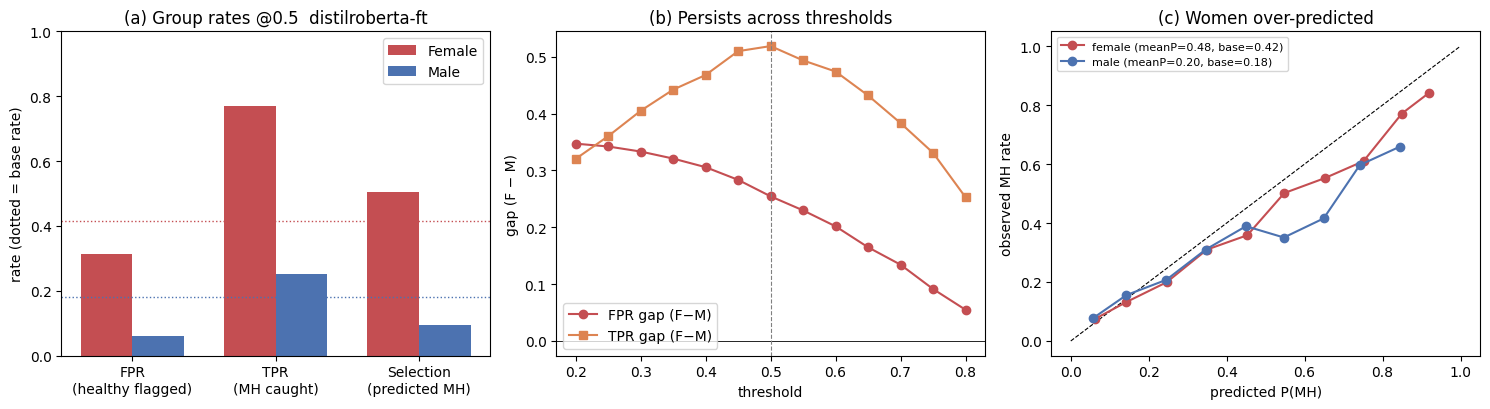

In [6]:
# ── Summary figure ───────────────────────────────────────────────────────────
PRIMARY = 'distilroberta-ft'; prob = PRED[PRIMARY]
fm, mm = gender == 'female', gender == 'male'
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
yp = (prob >= 0.5).astype(int)
rf, rm = group_rates(y, yp, fm), group_rates(y, yp, mm)
mets = ['fpr', 'tpr', 'sel_rate']; labs = ['FPR\n(healthy flagged)', 'TPR\n(MH caught)', 'Selection\n(predicted MH)']
x = np.arange(3); w = 0.36
ax[0].bar(x-w/2, [rf[m] for m in mets], w, label='Female', color='#c44e52')
ax[0].bar(x+w/2, [rm[m] for m in mets], w, label='Male', color='#4c72b0')
ax[0].axhline(rf['base_rate'], ls=':', c='#c44e52', lw=1); ax[0].axhline(rm['base_rate'], ls=':', c='#4c72b0', lw=1)
ax[0].set_xticks(x); ax[0].set_xticklabels(labs); ax[0].set_ylim(0, 1)
ax[0].set_title(f'(a) Group rates @0.5  {PRIMARY}'); ax[0].legend(); ax[0].set_ylabel('rate (dotted = base rate)')
sw = sweep_df[sweep_df.model == PRIMARY].sort_values('thr')
ax[1].plot(sw.thr, sw.fpr_gap, 'o-', color='#c44e52', label='FPR gap (F−M)')
ax[1].plot(sw.thr, sw.tpr_gap, 's-', color='#dd8452', label='TPR gap (F−M)')
ax[1].axhline(0, c='k', lw=.6); ax[1].axvline(0.5, ls='--', c='gray', lw=.8)
ax[1].set_xlabel('threshold'); ax[1].set_ylabel('gap (F − M)'); ax[1].set_title('(b) Persists across thresholds'); ax[1].legend()
ax[2].plot([0, 1], [0, 1], 'k--', lw=.8)
for g, c in [('female', '#c44e52'), ('male', '#4c72b0')]:
    mk = gender == g; edges = np.linspace(0, 1, 11); xs, ys = [], []
    for lo, hi in zip(edges[:-1], edges[1:]):
        b = mk & (prob >= lo) & (prob < hi)
        if b.sum() > 20: xs.append(prob[b].mean()); ys.append(y[b].mean())
    ax[2].plot(xs, ys, 'o-', color=c, label=f'{g} (meanP={prob[mk].mean():.2f}, base={y[mk].mean():.2f})')
ax[2].set_xlabel('predicted P(MH)'); ax[2].set_ylabel('observed MH rate'); ax[2].set_title('(c) Women over-predicted'); ax[2].legend(fontsize=8)
plt.tight_layout(); plt.savefig(f'{OUT_DIR}/fairness_summary.png', dpi=150, bbox_inches='tight')
print('saved ->', f'{OUT_DIR}/fairness_summary.png')